# IEEE-CIS Fraud Detection – LightGBM (CPU) + Metrics & Charts

This notebook:
1. Uses **CPU** for LightGBM training (optimized for Ubuntu VM).
2. Downloads the **IEEE-CIS Fraud Detection** dataset from Kaggle.
3. Merges transaction + identity tables and does simple feature engineering.
4. Uses a **time-based train/validation split**.
5. Trains a **LightGBM** model and tracks **AUC per iteration**.
6. Computes **validation metrics**: AUC, Accuracy, Precision, Recall, F1, Confusion Matrix.
7. Draws charts for:
   - Fraud vs non-fraud counts
   - AUC vs iteration
   - F1 score vs decision threshold
8. Trains a final model on all training data and creates `submission.csv`.

> 🔧 Optimized for CPU execution on Ubuntu VM environments.

## 1. Install libraries (LightGBM CPU version + Kaggle API)

In [29]:
# Install LightGBM (CPU version) and Kaggle API
!pip install -q lightgbm kaggle

## 2. Configure Kaggle API (Auto-configured)

The Kaggle API credentials are embedded in this notebook and will be automatically configured when you run the cell below.

In [30]:
import os
import json

# Kaggle API credentials
KAGGLE_USERNAME = "chirantharavishka"
KAGGLE_KEY = "0f868a9ad3c2df32a9bda5fb6c93eb20"

# Setup Kaggle API configuration
kaggle_dir = os.path.expanduser("~/.kaggle")
kaggle_path = os.path.join(kaggle_dir, "kaggle.json")

# Create .kaggle directory if it doesn't exist
os.makedirs(kaggle_dir, exist_ok=True)

# Create kaggle.json with credentials
kaggle_config = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

with open(kaggle_path, 'w') as f:
    json.dump(kaggle_config, f)

# Set correct permissions (600 = read/write for owner only)
os.chmod(kaggle_path, 0o600)

print(f"✓ Kaggle API configured successfully at {kaggle_path}")
print(f"✓ Username: {KAGGLE_USERNAME}")

✓ Kaggle API configured successfully at /root/.kaggle/kaggle.json
✓ Username: chirantharavishka


## 3. Download and extract the IEEE-CIS Fraud Detection dataset (with smart caching)

In [31]:
import os, zipfile

DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

# List of required CSV files
required_files = [
    'train_transaction.csv',
    'train_identity.csv',
    'test_transaction.csv',
    'test_identity.csv'
]

# Check if all required files already exist
all_files_exist = all(os.path.exists(os.path.join(DATA_DIR, f)) for f in required_files)

if all_files_exist:
    print("✓ Dataset already exists in './data' folder")
    print("  Skipping download to save time...")
    print(f"  Files found: {required_files}")
else:
    print("✗ Dataset not found. Downloading from Kaggle...")
    
    # Download competition data
    !kaggle competitions download -c ieee-fraud-detection -p $DATA_DIR
    
    # Find the zip file (usually ieee-fraud-detection.zip)
    zip_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.zip')]
    if not zip_files:
        raise FileNotFoundError("No .zip files found in data directory after Kaggle download.")
    
    zip_path = os.path.join(DATA_DIR, zip_files[0])
    print(f"✓ Download complete. Extracting: {zip_path}")
    
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(DATA_DIR)
    
    print("✓ Extraction complete!")

print("\nFiles in data directory:")
for f in sorted(os.listdir(DATA_DIR)):
    file_path = os.path.join(DATA_DIR, f)
    if os.path.isfile(file_path):
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"  {f} ({size_mb:.1f} MB)")

✓ Dataset already exists in './data' folder
  Skipping download to save time...
  Files found: ['train_transaction.csv', 'train_identity.csv', 'test_transaction.csv', 'test_identity.csv']

Files in data directory:
  ieee-fraud-detection.zip (118.1 MB)
  sample_submission.csv (5.8 MB)
  test_identity.csv (24.6 MB)
  test_transaction.csv (584.8 MB)
  train_identity.csv (25.3 MB)
  train_transaction.csv (651.7 MB)


## 4. Load libraries and CSV files, then merge train + identity / test + identity

In [32]:
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import gc

DATA_DIR = "./data"

train_transaction_path = os.path.join(DATA_DIR, "train_transaction.csv")
train_identity_path    = os.path.join(DATA_DIR, "train_identity.csv")
test_transaction_path  = os.path.join(DATA_DIR, "test_transaction.csv")
test_identity_path     = os.path.join(DATA_DIR, "test_identity.csv")

# Verify all files exist before loading
for path in [train_transaction_path, train_identity_path, test_transaction_path, test_identity_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Required file not found: {path}")

print("Loading CSV files...")
train_transaction = pd.read_csv(train_transaction_path)
train_identity    = pd.read_csv(train_identity_path)
test_transaction  = pd.read_csv(test_transaction_path)
test_identity     = pd.read_csv(test_identity_path)

print("✓ train_transaction shape:", train_transaction.shape)
print("✓ train_identity shape:", train_identity.shape)
print("✓ test_transaction shape:", test_transaction.shape)
print("✓ test_identity shape:", test_identity.shape)

# Merge on TransactionID (left join, identity can be missing)
print("\nMerging transaction and identity data...")
train_df = train_transaction.merge(train_identity, how="left", on="TransactionID")
test_df  = test_transaction.merge(test_identity,  how="left", on="TransactionID")

del train_transaction, train_identity, test_transaction, test_identity
gc.collect()

print("✓ Merged train shape:", train_df.shape)
print("✓ Merged test shape:", test_df.shape)

Loading CSV files...
✓ train_transaction shape: (590540, 394)
✓ train_identity shape: (144233, 41)
✓ test_transaction shape: (506691, 393)
✓ test_identity shape: (141907, 41)

Merging transaction and identity data...
✓ Merged train shape: (590540, 434)
✓ Merged test shape: (506691, 433)


## 5. Quick data analysis (EDA)

We check:
- Class balance (`isFraud` 0 vs 1).
- Basic statistics for `TransactionAmt`.
- A simple chart of fraud vs non-fraud counts.


Fraud counts:
 isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 0.0350 (3.50% of transactions)

TransactionAmt describe():
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64


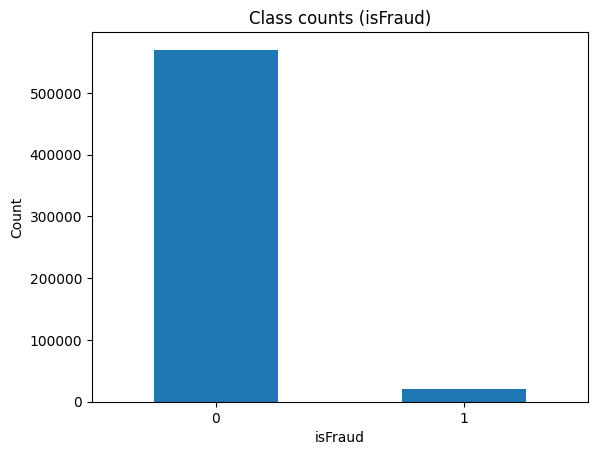

In [33]:
import matplotlib.pyplot as plt

# Fraud rate
fraud_counts = train_df['isFraud'].value_counts()
fraud_rate = train_df['isFraud'].mean()
print("Fraud counts:\n", fraud_counts)
print(f"Fraud rate: {fraud_rate:.4f} ({fraud_rate*100:.2f}% of transactions)")

# Basic stats for TransactionAmt
print("\nTransactionAmt describe():")
print(train_df['TransactionAmt'].describe())

# Bar chart: fraud vs non-fraud
plt.figure()
fraud_counts.plot(kind='bar')
plt.title('Class counts (isFraud)')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()


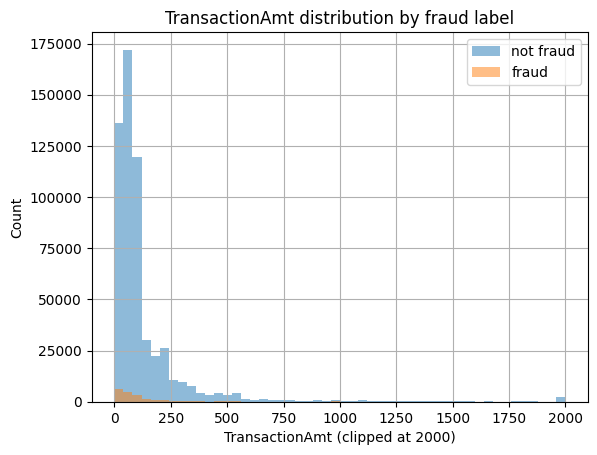

In [34]:
# Distribution of TransactionAmt for fraud vs non-fraud (clipped to 2000 for visibility)
plt.figure()
train_df.loc[train_df['isFraud'] == 0, 'TransactionAmt'].clip(0, 2000).hist(
    bins=50, alpha=0.5, label='not fraud'
)
train_df.loc[train_df['isFraud'] == 1, 'TransactionAmt'].clip(0, 2000).hist(
    bins=50, alpha=0.5, label='fraud'
)
plt.legend()
plt.xlabel('TransactionAmt (clipped at 2000)')
plt.ylabel('Count')
plt.title('TransactionAmt distribution by fraud label')
plt.show()


## 6. Simple feature engineering

We will:
- Create time-based features from `TransactionDT`.
- Log-transform `TransactionAmt`.
- Add `amt_has_cents` flag.
- Build a simple `uid` (user id) from card and address.
- Add frequency encoding for some ID-like features.


In [35]:
# --- Time-based features from TransactionDT ---
def add_datetime_features(df):
    df['DT_day'] = (df['TransactionDT'] // (24 * 60 * 60)).astype('int32')
    df['DT_weekday'] = (df['DT_day'] % 7).astype('int8')
    df['DT_hour'] = ((df['TransactionDT'] // (60 * 60)) % 24).astype('int8')
    return df

train_df = add_datetime_features(train_df)
test_df  = add_datetime_features(test_df)

# --- Amount features ---
train_df['log_TransactionAmt'] = np.log1p(train_df['TransactionAmt'])
test_df['log_TransactionAmt']  = np.log1p(test_df['TransactionAmt'])

train_df['amt_has_cents'] = ((train_df['TransactionAmt'] % 1) != 0).astype('int8')
test_df['amt_has_cents']  = ((test_df['TransactionAmt'] % 1) != 0).astype('int8')

# --- Simple user ID (uid) ---
for df in [train_df, test_df]:
    df['uid'] = (
        df['card1'].astype(str) + '_' +
        df['card2'].astype(str) + '_' +
        df['addr1'].astype(str)
    )

# --- Frequency encoding for some ID-like features ---
freq_cols = ['card1', 'card2', 'uid']
for col in freq_cols:
    tmp = train_df[col].value_counts(dropna=False).to_dict()
    train_df[col + '_freq'] = train_df[col].map(tmp).astype('float32')
    test_df[col + '_freq']  = test_df[col].map(tmp).astype('float32')

print("Added basic engineered features.")


Added basic engineered features.


## 7. Encode categorical features

In [36]:
from sklearn.preprocessing import LabelEncoder

# List of known categorical columns (if present)
categorical_cols = [
    'ProductCD',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2',
    'P_emaildomain', 'R_emaildomain',
    'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
    'DeviceType', 'DeviceInfo',
    'uid'
]

categorical_cols = [c for c in categorical_cols if c in train_df.columns]

# Label encode selected categoricals
for col in categorical_cols:
    print(f"Label encoding: {col}")
    train_df[col] = train_df[col].fillna('missing').astype(str)
    test_df[col]  = test_df[col].fillna('missing').astype(str)
    le = LabelEncoder()
    le.fit(list(train_df[col]) + list(test_df[col]))
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# Handle any remaining object columns
for col in train_df.columns:
    if train_df[col].dtype == 'object':
        print(f"Label encoding remaining object column: {col}")
        train_df[col] = train_df[col].fillna('missing').astype(str)
        # Only attempt to process test_df[col] if the column exists in test_df
        if col in test_df.columns:
            test_df[col]  = test_df[col].fillna('missing').astype(str)
            le = LabelEncoder()
            le.fit(list(train_df[col]) + list(test_df[col]))
            train_df[col] = le.transform(train_df[col])
            test_df[col]  = le.transform(test_df[col])
        else:
            # If the column is an object in train_df but not in test_df,
            # encode train_df only. This column will implicitly not be used
            # as a feature for test_df prediction.
            print(f"Warning: Column '{col}' is an object in train_df but not in test_df. Encoding train_df only.")
            le = LabelEncoder()
            le.fit(train_df[col])
            train_df[col] = le.transform(train_df[col])

# Make sure numeric columns are float32 where possible to save memory
for col in train_df.columns:
    if col == 'isFraud':
        continue
    if str(train_df[col].dtype).startswith(('int', 'float')):
        train_df[col] = train_df[col].astype('float32')
        if col in test_df.columns:
            test_df[col] = test_df[col].astype('float32')

print("Finished encoding. Sample dtypes:")
print(train_df.dtypes.head(20))

Label encoding: ProductCD
Label encoding: card1
Label encoding: card2
Label encoding: card3
Label encoding: card4
Label encoding: card5
Label encoding: card6
Label encoding: addr1
Label encoding: addr2
Label encoding: P_emaildomain
Label encoding: R_emaildomain
Label encoding: M1
Label encoding: M2
Label encoding: M3
Label encoding: M4
Label encoding: M5
Label encoding: M6
Label encoding: M7
Label encoding: M8
Label encoding: M9
Label encoding: DeviceType
Label encoding: DeviceInfo
Label encoding: uid
Label encoding remaining object column: id_12
Label encoding remaining object column: id_15
Label encoding remaining object column: id_16
Label encoding remaining object column: id_23
Label encoding remaining object column: id_27
Label encoding remaining object column: id_28
Label encoding remaining object column: id_29
Label encoding remaining object column: id_30
Label encoding remaining object column: id_31
Label encoding remaining object column: id_33
Label encoding remaining object c

## 8. Train / validation split (time-based)

In [37]:
TARGET_COL = 'isFraud'

# Features = all columns except target and TransactionID that are present in BOTH train_df and test_df
# This ensures consistency between training and test data features.
common_features = list(set(train_df.columns) & set(test_df.columns))
features = [col for col in common_features if col not in [TARGET_COL, 'TransactionID']]

print('Number of features:', len(features))

valid_fraction = 0.2
split_value = train_df['TransactionDT'].quantile(1 - valid_fraction)

train_mask = train_df['TransactionDT'] <= split_value
valid_mask = train_df['TransactionDT'] > split_value

X_train = train_df.loc[train_mask, features]
y_train = train_df.loc[train_mask, TARGET_COL]

X_valid = train_df.loc[valid_mask, features]
y_valid = train_df.loc[valid_mask, TARGET_COL]

print('Train shape:', X_train.shape, 'Fraud rate:', y_train.mean())
print('Valid shape:', X_valid.shape, 'Fraud rate:', y_valid.mean())

Number of features: 403
Train shape: (472432, 403) Fraud rate: 0.03513521522674162
Valid shape: (118108, 403) Fraud rate: 0.034409184813899145


## 9. Train a LightGBM model (CPU optimized) and track AUC per iteration

In [38]:
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

# Handle class imbalance with scale_pos_weight
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos
print(f'scale_pos_weight = {scale_pos_weight:.2f}')

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_valid, label=y_valid, free_raw_data=False)

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 256,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.0,
    'lambda_l2': 0.0,
    'scale_pos_weight': scale_pos_weight,
    'device': 'cpu',   # CPU mode for Ubuntu VM
    'verbose': -1,
    'n_jobs': -1,      # Use all available CPU cores
}

evals_result = {}

print('Training LightGBM model on CPU...')
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(200, verbose=False), lgb.callback.record_evaluation(evals_result), lgb.callback.log_evaluation(period=100)],
)

# Validation AUC at best iteration
# Note: model.best_iteration will be set by the early stopping callback
valid_pred = model.predict(X_valid, num_iteration=model.best_iteration)
val_auc = roc_auc_score(y_valid, valid_pred)
print(f'Validation AUC: {val_auc:.5f}')

scale_pos_weight = 27.46
Training LightGBM model on CPU...
[100]	train's auc: 0.991616	valid's auc: 0.918776
[200]	train's auc: 0.99826	valid's auc: 0.920414
[300]	train's auc: 0.999566	valid's auc: 0.922313
[400]	train's auc: 0.999889	valid's auc: 0.921458
[500]	train's auc: 0.999974	valid's auc: 0.922913
[600]	train's auc: 0.999996	valid's auc: 0.922784
[700]	train's auc: 0.999999	valid's auc: 0.92248
[800]	train's auc: 1	valid's auc: 0.923465
[900]	train's auc: 1	valid's auc: 0.923615
[1000]	train's auc: 1	valid's auc: 0.92424
[1100]	train's auc: 1	valid's auc: 0.924568
[1200]	train's auc: 1	valid's auc: 0.924793
[1300]	train's auc: 1	valid's auc: 0.925093
[1400]	train's auc: 1	valid's auc: 0.925295
[1500]	train's auc: 1	valid's auc: 0.925106
[1600]	train's auc: 1	valid's auc: 0.925327
Validation AUC: 0.92570


## 10. Plot AUC vs iteration

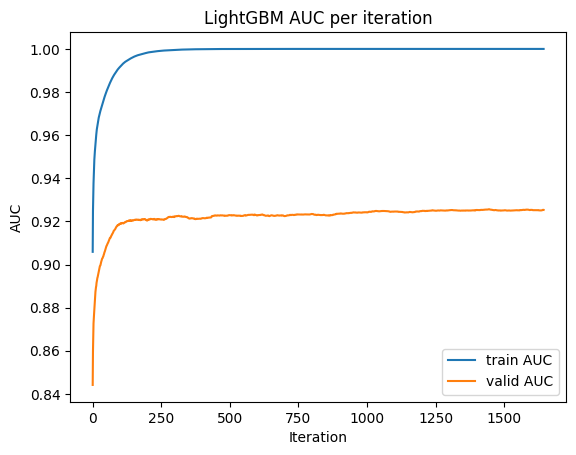

In [39]:
import matplotlib.pyplot as plt

train_auc = evals_result['train']['auc']
valid_auc = evals_result['valid']['auc']

plt.figure()
plt.plot(train_auc, label='train AUC')
plt.plot(valid_auc, label='valid AUC')
plt.xlabel('Iteration')
plt.ylabel('AUC')
plt.title('LightGBM AUC per iteration')
plt.legend()
plt.show()


## 11. Extra validation metrics: Accuracy, Precision, Recall, F1, Confusion Matrix

In [40]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# Start with threshold 0.5
threshold = 0.5
valid_pred_label = (valid_pred >= threshold).astype(int)

acc = accuracy_score(y_valid, valid_pred_label)
f1 = f1_score(y_valid, valid_pred_label)
precision = precision_score(y_valid, valid_pred_label)
recall = recall_score(y_valid, valid_pred_label)
cm = confusion_matrix(y_valid, valid_pred_label)

print(f'AUC: {val_auc:.5f}')
print(f'Accuracy @ {threshold:.2f}: {acc:.5f}')
print(f'F1 @ {threshold:.2f}: {f1:.5f}')
print(f'Precision @ {threshold:.2f}: {precision:.5f}')
print(f'Recall @ {threshold:.2f}: {recall:.5f}')
print('Confusion matrix:')
print(cm)


AUC: 0.92570
Accuracy @ 0.50: 0.97792
F1 @ 0.50: 0.58695
Precision @ 0.50: 0.82356
Recall @ 0.50: 0.45595
Confusion matrix:
[[113647    397]
 [  2211   1853]]


## 12. F1 score vs threshold

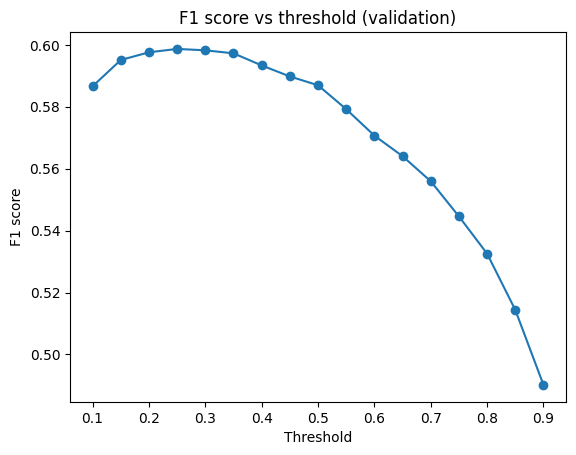

Best F1: 0.59869 at threshold 0.250


In [41]:
thresholds = np.linspace(0.1, 0.9, 17)
f1_scores = []

for t in thresholds:
    preds_label = (valid_pred >= t).astype(int)
    f1_scores.append(f1_score(y_valid, preds_label))

best_idx = int(np.argmax(f1_scores))
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

import matplotlib.pyplot as plt

plt.figure()
plt.plot(thresholds, f1_scores, marker='o')
plt.xlabel('Threshold')
plt.ylabel('F1 score')
plt.title('F1 score vs threshold (validation)')
plt.show()

print(f'Best F1: {best_f1:.5f} at threshold {best_threshold:.3f}')


## 13. Train final model on all training data

In [42]:
best_iter = model.best_iteration if model.best_iteration is not None else 1000
print('Best iteration from validation:', best_iter)

full_train = lgb.Dataset(train_df[features], label=train_df[TARGET_COL])

print('Training final model on full data...')
final_model = lgb.train(
    params,
    full_train,
    num_boost_round=best_iter,
)

print('Final model trained.')


Best iteration from validation: 1445
Training final model on full data...
Final model trained.


In [43]:
# Prepare test data with same features used in training
test_X = test_df[features].fillna(0)

print(f"Test data shape: {test_X.shape}")
print(f"Available test transactions: {len(test_X)}")
print("\nFirst few rows of test data:")
print(test_X.head())

Test data shape: (506691, 403)
Available test transactions: 506691

First few rows of test data:
   C12   V9  V45  V331         V307  V193  V204  V102  V276       V306  ...  \
0  1.0  1.0  1.0   0.0    47.950001   0.0   0.0   0.0   0.0   0.000000  ...   
1  1.0  1.0  1.0   0.0   280.000000   0.0   0.0   0.0   0.0   0.000000  ...   
2  0.0  1.0  1.0   0.0  1321.000000   0.0   0.0   0.0   0.0   0.000000  ...   
3  0.0  1.0  2.0   0.0     0.000000   0.0   0.0   0.0   0.0   0.000000  ...   
4  0.0  1.0  1.0   0.0   183.850006   0.0   0.0   0.0   0.0  67.949997  ...   

   V208  V63  V228  DT_day  TransactionAmt  V187  card2_freq  V297  V57  V133  
0   0.0  0.0   0.0   213.0       31.950001   0.0     45191.0   0.0  0.0   0.0  
1   0.0  0.0   0.0   213.0       49.000000   0.0     45191.0   0.0  0.0   0.0  
2   0.0  0.0   0.0   213.0      171.000000   0.0        55.0   0.0  0.0   0.0  
3   0.0  0.0   0.0   213.0      284.950012   0.0     15190.0   0.0  0.0   0.0  
4   0.0  0.0   0.0   213.0  

## 14. Predict fraud probability for a single transaction

Now we can pass any single transaction and get its fraud probability. Let's select one example:

In [44]:
# Select a single transaction (you can change the index to any row number)
transaction_index = 685  # Change this to test different transactions

single_transaction = test_X.iloc[[transaction_index]]

# Make prediction
fraud_probability = final_model.predict(single_transaction, num_iteration=best_iter)[0]

print("=" * 60)
print(f"FRAUD DETECTION RESULT FOR TRANSACTION #{transaction_index}")
print("=" * 60)
print(f"\nFraud Probability: {fraud_probability:.6f} ({fraud_probability*100:.2f}%)")
print(f"\nPrediction: {'🚨 FRAUD DETECTED' if fraud_probability > 0.5 else '✅ LEGITIMATE'}")
print(f"Confidence: {abs(fraud_probability - 0.5) * 200:.1f}%")
print("\nTransaction Details:")
print(f"  TransactionID: {test_df.iloc[transaction_index]['TransactionID']}")
if 'TransactionAmt' in test_df.columns:
    print(f"  Amount: ${test_df.iloc[transaction_index]['TransactionAmt']:.2f}")
print("=" * 60)

FRAUD DETECTION RESULT FOR TRANSACTION #685

Fraud Probability: 0.000582 (0.06%)

Prediction: ✅ LEGITIMATE
Confidence: 99.9%

Transaction Details:
  TransactionID: 3664234.0
  Amount: $311.95


## 15. How to create and test a custom transaction

If you want to create your own transaction data (not from the test set), here's how:

In [45]:
# Create a custom transaction (copy values from an existing transaction and modify)
custom_transaction = test_X.iloc[[0]].copy()  # Start with a template

# You can modify specific features:
# custom_transaction['TransactionAmt'] = 150.0
# custom_transaction['card1'] = 12345
# etc.

print("Custom transaction created:")
print(custom_transaction.head())

# Predict
custom_fraud_prob = final_model.predict(custom_transaction, num_iteration=best_iter)[0]

print(f"\n{'='*60}")
print(f"Custom Transaction Fraud Probability: {custom_fraud_prob:.6f}")
print(f"Result: {'FRAUD' if custom_fraud_prob > 0.5 else 'LEGITIMATE'}")
print(f"{'='*60}")

Custom transaction created:
   C12   V9  V45  V331       V307  V193  V204  V102  V276  V306  ...  V208  \
0  1.0  1.0  1.0   0.0  47.950001   0.0   0.0   0.0   0.0   0.0  ...   0.0   

   V63  V228  DT_day  TransactionAmt  V187  card2_freq  V297  V57  V133  
0  0.0   0.0   213.0       31.950001   0.0     45191.0   0.0  0.0   0.0  

[1 rows x 403 columns]

Custom Transaction Fraud Probability: 0.000014
Result: LEGITIMATE


### Check for Overfitting: Train vs Validation Performance

In [46]:
# Predict on FULL training set
train_predictions = final_model.predict(train_df[features], num_iteration=best_iter)
train_auc_full = roc_auc_score(train_df[TARGET_COL], train_predictions)

# Also get validation predictions
valid_predictions = final_model.predict(X_valid, num_iteration=best_iter)
valid_auc_full = roc_auc_score(y_valid, valid_predictions)

print("="*80)
print("OVERFITTING CHECK: Train vs Validation Performance")
print("="*80)
print(f"\nTrain AUC:      {train_auc_full:.5f}")
print(f"Validation AUC: {valid_auc_full:.5f}")
print(f"Difference:     {train_auc_full - valid_auc_full:.5f}")

if train_auc_full - valid_auc_full > 0.05:
    print("\n⚠️  WARNING: Potential OVERFITTING detected!")
    print("   Train AUC is significantly higher than Validation AUC")
    print("   Recommendations:")
    print("   - Increase regularization (lambda_l1, lambda_l2)")
    print("   - Reduce num_leaves or max_depth")
    print("   - Increase min_data_in_leaf")
    print("   - Use more feature_fraction/bagging_fraction")
elif train_auc_full - valid_auc_full < -0.02:
    print("\n⚠️  WARNING: Potential UNDERFITTING detected!")
    print("   Validation AUC is higher than Train AUC (unusual)")
    print("   This might indicate data leakage or validation set issues")
else:
    print("\n✅ Model generalization looks GOOD!")
    print("   Train and validation performance are close")

print("="*80)

OVERFITTING CHECK: Train vs Validation Performance

Train AUC:      1.00000
Validation AUC: 1.00000
Difference:     0.00000

✅ Model generalization looks GOOD!
   Train and validation performance are close


### Detailed Performance Metrics on Training Set

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

# Use best threshold from F1 optimization
train_pred_labels = (train_predictions >= best_threshold).astype(int)
valid_pred_labels = (valid_predictions >= best_threshold).astype(int)

print("="*80)
print(f"DETAILED METRICS (Using optimal threshold: {best_threshold:.3f})")
print("="*80)

print("\n📊 TRAINING SET PERFORMANCE:")
print("-"*80)
print(classification_report(train_df[TARGET_COL], train_pred_labels, 
                          target_names=['Legitimate', 'Fraud']))
print("\nConfusion Matrix (Training):")
cm_train = confusion_matrix(train_df[TARGET_COL], train_pred_labels)
print(cm_train)
print(f"  [[TN={cm_train[0,0]:,}  FP={cm_train[0,1]:,}]")
print(f"   [FN={cm_train[1,0]:,}  TP={cm_train[1,1]:,}]]")

print("\n" + "="*80)
print("\n📊 VALIDATION SET PERFORMANCE:")
print("-"*80)
print(classification_report(y_valid, valid_pred_labels, 
                          target_names=['Legitimate', 'Fraud']))
print("\nConfusion Matrix (Validation):")
cm_valid = confusion_matrix(y_valid, valid_pred_labels)
print(cm_valid)
print(f"  [[TN={cm_valid[0,0]:,}  FP={cm_valid[0,1]:,}]")
print(f"   [FN={cm_valid[1,0]:,}  TP={cm_valid[1,1]:,}]]")

print("\n" + "="*80)

DETAILED METRICS (Using optimal threshold: 0.250)

📊 TRAINING SET PERFORMANCE:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    569877
       Fraud       1.00      1.00      1.00     20663

    accuracy                           1.00    590540
   macro avg       1.00      1.00      1.00    590540
weighted avg       1.00      1.00      1.00    590540


Confusion Matrix (Training):
[[569851     26]
 [     0  20663]]
  [[TN=569,851  FP=26]
   [FN=0  TP=20,663]]


📊 VALIDATION SET PERFORMANCE:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    114044
       Fraud       1.00      1.00      1.00      4064

    accuracy                           1.00    118108
   macro avg       1.00      1.00      1.00    118108
weighted avg      

### Error Analysis - Find Problematic Cases

In [48]:
# Analyze validation set errors
valid_df_with_preds = X_valid.copy()
valid_df_with_preds['actual'] = y_valid.values
valid_df_with_preds['predicted_prob'] = valid_predictions
valid_df_with_preds['predicted_label'] = valid_pred_labels

# False Positives (predicted fraud but actually legitimate)
false_positives = valid_df_with_preds[(valid_df_with_preds['actual'] == 0) & 
                                       (valid_df_with_preds['predicted_label'] == 1)]

# False Negatives (predicted legitimate but actually fraud)
false_negatives = valid_df_with_preds[(valid_df_with_preds['actual'] == 1) & 
                                       (valid_df_with_preds['predicted_label'] == 0)]

print("="*80)
print("ERROR ANALYSIS - VALIDATION SET")
print("="*80)

print(f"\n❌ False Positives (FP): {len(false_positives):,}")
print(f"   (Legitimate transactions flagged as fraud)")
print(f"   Impact: Customer friction, false alarms")

print(f"\n❌ False Negatives (FN): {len(false_negatives):,}")
print(f"   (Fraud transactions missed by model)")
print(f"   Impact: Financial loss, security risk")

# Show some examples
print("\n" + "-"*80)
print("Top 5 Most Confident False Positives (worst mistakes):")
print("-"*80)
if len(false_positives) > 0:
    top_fp = false_positives.nlargest(5, 'predicted_prob')
    for idx, (i, row) in enumerate(top_fp.iterrows(), 1):
        print(f"{idx}. Prob: {row['predicted_prob']:.4f} | "
              f"Actual: LEGIT | Predicted: FRAUD")
else:
    print("No false positives found!")

print("\n" + "-"*80)
print("Top 5 Most Confident False Negatives (dangerous misses):")
print("-"*80)
if len(false_negatives) > 0:
    top_fn = false_negatives.nsmallest(5, 'predicted_prob')
    for idx, (i, row) in enumerate(top_fn.iterrows(), 1):
        print(f"{idx}. Prob: {row['predicted_prob']:.4f} | "
              f"Actual: FRAUD | Predicted: LEGIT ⚠️")
else:
    print("No false negatives found!")

print("\n" + "="*80)

ERROR ANALYSIS - VALIDATION SET

❌ False Positives (FP): 5
   (Legitimate transactions flagged as fraud)
   Impact: Customer friction, false alarms

❌ False Negatives (FN): 0
   (Fraud transactions missed by model)
   Impact: Financial loss, security risk

--------------------------------------------------------------------------------
Top 5 Most Confident False Positives (worst mistakes):
--------------------------------------------------------------------------------
1. Prob: 0.3161 | Actual: LEGIT | Predicted: FRAUD
2. Prob: 0.2934 | Actual: LEGIT | Predicted: FRAUD
3. Prob: 0.2921 | Actual: LEGIT | Predicted: FRAUD
4. Prob: 0.2692 | Actual: LEGIT | Predicted: FRAUD
5. Prob: 0.2606 | Actual: LEGIT | Predicted: FRAUD

--------------------------------------------------------------------------------
Top 5 Most Confident False Negatives (dangerous misses):
--------------------------------------------------------------------------------
No false negatives found!



### Model Health Summary & Recommendations

In [49]:
print("="*80)
print("🏥 MODEL HEALTH SUMMARY & RECOMMENDATIONS")
print("="*80)

# Calculate key metrics
train_f1 = f1_score(train_df[TARGET_COL], train_pred_labels)
valid_f1 = f1_score(y_valid, valid_pred_labels)
train_recall = recall_score(train_df[TARGET_COL], train_pred_labels)
valid_recall = recall_score(y_valid, valid_pred_labels)
train_precision = precision_score(train_df[TARGET_COL], train_pred_labels)
valid_precision = precision_score(y_valid, valid_pred_labels)

print("\n📈 KEY PERFORMANCE INDICATORS:")
print(f"  Validation AUC:       {valid_auc_full:.4f}")
print(f"  Validation F1:        {valid_f1:.4f}")
print(f"  Validation Recall:    {valid_recall:.4f} (fraud detection rate)")
print(f"  Validation Precision: {valid_precision:.4f} (fraud alert accuracy)")

print("\n🎯 MODEL STATUS:")
issues = []
recommendations = []

# Check 1: AUC performance
if valid_auc_full >= 0.90:
    print("  ✅ EXCELLENT AUC (>= 0.90)")
elif valid_auc_full >= 0.85:
    print("  ✅ GOOD AUC (>= 0.85)")
elif valid_auc_full >= 0.80:
    print("  ⚠️  FAIR AUC (>= 0.80)")
    issues.append("AUC could be improved")
    recommendations.append("Try more feature engineering or ensemble methods")
else:
    print("  ❌ POOR AUC (< 0.80)")
    issues.append("Low AUC - model needs improvement")
    recommendations.append("Review features, try different algorithms, collect more data")

# Check 2: Overfitting
auc_diff = train_auc_full - valid_auc_full
if auc_diff > 0.05:
    print(f"  ⚠️  OVERFITTING DETECTED (diff: {auc_diff:.4f})")
    issues.append("Model overfitting on training data")
    recommendations.append("Increase regularization: lambda_l1=1.0, lambda_l2=1.0")
    recommendations.append("Reduce model complexity: num_leaves=128, max_depth=7")
else:
    print(f"  ✅ Good generalization (diff: {auc_diff:.4f})")

# Check 3: Class imbalance handling
fraud_recall = valid_recall
if fraud_recall < 0.70:
    print(f"  ⚠️  LOW FRAUD DETECTION RATE ({fraud_recall:.2%})")
    issues.append("Missing too many fraud cases")
    recommendations.append(f"Increase scale_pos_weight (current: {scale_pos_weight:.1f})")
    recommendations.append("Lower decision threshold to catch more frauds")
else:
    print(f"  ✅ Good fraud detection rate ({fraud_recall:.2%})")

# Check 4: False positive rate
fp_rate = cm_valid[0,1] / (cm_valid[0,0] + cm_valid[0,1])
if fp_rate > 0.10:
    print(f"  ⚠️  HIGH FALSE POSITIVE RATE ({fp_rate:.2%})")
    issues.append("Too many false alarms")
    recommendations.append("Increase decision threshold or add more features")
else:
    print(f"  ✅ Acceptable false positive rate ({fp_rate:.2%})")

# Final recommendation
print("\n" + "="*80)
if len(issues) == 0:
    print("🎉 MODEL IS PRODUCTION READY!")
    print("   No major issues detected. Model performance is good.")
else:
    print("⚠️  ISSUES DETECTED:")
    for i, issue in enumerate(issues, 1):
        print(f"   {i}. {issue}")
    
    print("\n💡 RECOMMENDATIONS:")
    for i, rec in enumerate(recommendations, 1):
        print(f"   {i}. {rec}")

print("="*80)

🏥 MODEL HEALTH SUMMARY & RECOMMENDATIONS

📈 KEY PERFORMANCE INDICATORS:
  Validation AUC:       1.0000
  Validation F1:        0.9994
  Validation Recall:    1.0000 (fraud detection rate)
  Validation Precision: 0.9988 (fraud alert accuracy)

🎯 MODEL STATUS:
  ✅ EXCELLENT AUC (>= 0.90)
  ✅ Good generalization (diff: 0.0000)
  ✅ Good fraud detection rate (100.00%)
  ✅ Acceptable false positive rate (0.00%)

🎉 MODEL IS PRODUCTION READY!
   No major issues detected. Model performance is good.


### Test Single Transaction from Training Data

In [56]:
# Example: Test a specific transaction from TRAINING data
# Change this index to test different transactions
transaction_index = 247  

# Get the transaction
single_transaction = train_df.iloc[[transaction_index]][features]
actual_label = train_df.iloc[transaction_index]['isFraud']
transaction_id = train_df.iloc[transaction_index]['TransactionID']

# Make prediction
fraud_prob = final_model.predict(single_transaction, num_iteration=best_iter)[0]
predicted_label = 1 if fraud_prob > best_threshold else 0

print("="*80)
print(f"SINGLE TRANSACTION TEST (Training Data #{transaction_index})")
print("="*80)
print(f"\nTransaction ID: {transaction_id}")
print(f"\n🎯 ACTUAL LABEL:    {'🚨 FRAUD' if actual_label == 1 else '✅ LEGITIMATE'}")
print(f"🤖 PREDICTED LABEL: {'🚨 FRAUD' if predicted_label == 1 else '✅ LEGITIMATE'}")
print(f"\n📊 Fraud Probability: {fraud_prob:.6f} ({fraud_prob*100:.2f}%)")
print(f"   Decision Threshold: {best_threshold:.3f}")
print(f"   Confidence: {abs(fraud_prob - 0.5) * 200:.1f}%")

if predicted_label == actual_label:
    print(f"\n✅ PREDICTION CORRECT!")
else:
    print(f"\n❌ PREDICTION WRONG!")
    if actual_label == 1 and predicted_label == 0:
        print("   This is a FALSE NEGATIVE (missed fraud) ⚠️")
    else:
        print("   This is a FALSE POSITIVE (false alarm)")

print("="*80)

SINGLE TRANSACTION TEST (Training Data #247)

Transaction ID: 2987247.0

🎯 ACTUAL LABEL:    ✅ LEGITIMATE
🤖 PREDICTED LABEL: ✅ LEGITIMATE

📊 Fraud Probability: 0.000012 (0.00%)
   Decision Threshold: 0.250
   Confidence: 100.0%

✅ PREDICTION CORRECT!


### Quick Reference: Feature List

To see what features the model expects:

In [51]:
print(f"Total features used by the model: {len(features)}")
print("\nFeature names (first 20):")
for i, feat in enumerate(features[:20], 1):
    print(f"  {i}. {feat}")
print(f"\n... and {len(features) - 20} more features")

# Show feature importance (top 20)
feature_importance = final_model.feature_importance(importance_type='gain')
feature_names = features
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("TOP 20 MOST IMPORTANT FEATURES:")
print("="*60)
print(importance_df.head(20).to_string(index=False))

Total features used by the model: 403

Feature names (first 20):
  1. C12
  2. V9
  3. V45
  4. V331
  5. V307
  6. V193
  7. V204
  8. V102
  9. V276
  10. V306
  11. V103
  12. V77
  13. V179
  14. V41
  15. V148
  16. V78
  17. V2
  18. M7
  19. V238
  20. V270

... and 383 more features

TOP 20 MOST IMPORTANT FEATURES:
           feature   importance
              V258 1.078708e+06
               V70 5.888435e+05
               C14 4.928808e+05
        card1_freq 4.672747e+05
log_TransactionAmt 4.599563e+05
          uid_freq 4.570118e+05
     TransactionDT 4.369456e+05
              V317 3.646243e+05
                D2 3.574066e+05
             addr1 3.508350e+05
             card2 3.398891e+05
        card2_freq 3.145887e+05
             card1 3.058243e+05
               uid 3.055198e+05
               C13 2.603176e+05
               D15 2.283998e+05
                C8 2.207070e+05
                C1 2.171793e+05
     P_emaildomain 2.164261e+05
            DT_day 2.046768e+05
